In [204]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from functionsEawag import *
import scipy as sci
from matplotlib import cm, colors


def get_depth_with_swiss_coords(xsc,ysc,bathy):

    """
    get the depth at a point
    
    In=2 float : x and y, swiss coords 
    and a data_set bathymetric, with xsc, and ysc in coords

    Out= float, depth
    """
    xsc,ysc=int(xsc),int(ysc)
    i,j=np.argmin(np.abs(bathy.xsc.values-xsc)),np.argmin(np.abs(bathy.ysc.values-ysc))
    
    return bathy.depth[j,i].item()

def interpolate(x_data,y_data,n=3):

    """
    decrease the size of a step in data
    (linear interpolate)
    
    In=2 array, data, eventually nb of point btwn
    Out= these 2 array, with more points

    """
    x_newdata=[x_data[0]]
    y_newdata=[y_data[0]]
    for i in range(len(x_data)-1):
        
        stepx= x_data[i+1]-x_data[i]
        stepy= y_data[i+1]-y_data[i]
        
        for j in range(n):
            x_newdata.append(x_data[i]+(j*stepx/n))
            y_newdata.append(y_data[i]+(j*stepy/n))


    return x_newdata,y_newdata

def plot_and_TF(datafunc,adcpcorrfunc,dataname='dataname'):

    """
    In=Tableau de valeur 
    Out= plot in time, and calculate the TF
    """
    
    dt=(adcpcorrfunc.time.values[1]-adcpcorrfunc.time.values[0])/np.timedelta64(1,'s')
    
    TF=np.fft.fft(datafunc-np.mean(datafunc))
    freq=np.fft.fftfreq(np.shape(datafunc)[-1],d=dt)
    
    print(f'mean of data = {np.mean(datafunc).item()}')

    g = np.ones(10)/10
    FFTsmooth = np.convolve(np.abs(TF),g,'same')

    
    fig,ax=plt.subplots(2,1)

    ax[0].plot(adcpcorrfunc.time,datafunc)
    ax[0].set_ylabel(dataname)
    ax[0].set_xlabel('time')


    ax[1].loglog(freq,FFTsmooth)

    ax[1].set_ylabel('FFT temp')
    ax[1].set_xlabel('freq(s-1)')
    plt.show()

    return TF,freq


# Bathy

In [6]:
fp='../data/bathymetry.nc'
bathy=xr.open_dataset(fp)
bathy

c:\Users\termesid\AppData\Local\anaconda3\envs\ewg\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<xarray.Dataset> Size: 5GB
Dimensions:  (ysc: 21421, xsc: 26497)
Coordinates:
  * ysc      (ysc) int64 171kB 1193664 1193665 1193666 ... 1215083 1215084
  * xsc      (xsc) int64 212kB 2663921 2663922 2663923 ... 2690416 2690417
Data variables:
    depth    (ysc, xsc) float64 5GB ...

# Profil

C:\Users\termesid\AppData\Local\Temp\ipykernel_34476\3809311624.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap()
c:\Users\termesid\AppData\Local\anaconda3\envs\ewg\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


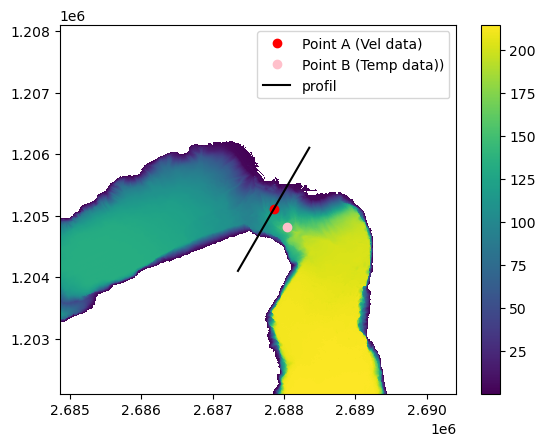

In [ ]:
posxA,posyA=2687855,1205104

posxB,posyB=2688036,1204812

newbathy= bathy.sel(xsc=slice(posxA-3000,posxA+3000),ysc=slice(posyA-3000,posyA+3000))

fig,ax = plt.subplots()


ax.pcolormesh(newbathy.xsc,newbathy.ysc,newbathy.depth)

cmap = cm.get_cmap()
norm = colors.Normalize(bathy.depth.min().item(), bathy.depth.max().item())

fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
ax.plot(posxA,posyA,'o',color='red',label="Point A (Vel data)")
#ax.plot(posxB ,posyB,'o',color='pink',label="Point B (Temp data))")
ax.plot([posxA-500,posxA+500],[posyA-1000,posyA+1000],color='black',label='profil')

ax.legend()
plt.show()

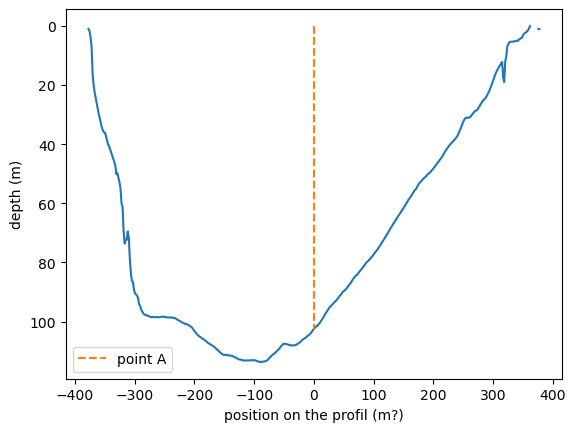

In [8]:
depthprofil=np.array([get_depth_with_swiss_coords(posxA+i,posyA+2*i,bathy) for i in range(-500,501)])
coordsprofil=np.array([i for i in range(-500,501)])*np.sqrt(3)



fig,ax=plt.subplots()
ax.plot(coordsprofil,depthprofil)
ax.plot([0,0],[0,get_depth_with_swiss_coords(posxA,posyA,bathy)],linestyle='--',label='point A')
ax.invert_yaxis()
ax.legend()
ax.set_xlabel('position on the profil (m?)')
ax.set_ylabel('depth (m)')
plt.show()

In [9]:
depthprofil[np.isnan(depthprofil)]=0
surface=  sci.integrate.trapezoid(depthprofil,coordsprofil)
print(f'surface = {surface} m2')

surface = 54407.64277132935 m2


# ADCP

In [10]:
os.listdir('../data/adcp/')
fp='../data/adcp/MUO1_UP_03_23.nc'
adcp=xr.open_dataset(fp)
adcp

<xarray.Dataset> Size: 18MB
Dimensions:              (time: 13999, dir: 4, range: 40, beam: 4, x: 4, x*: 4,
                          earth: 3, inst: 3)
Coordinates:
  * time                 (time) datetime64[ns] 112kB 2023-03-31T06:00:00 ... ...
  * dir                  (dir) <U3 48B 'E' 'N' 'U' 'err'
  * range                (range) float64 320B 3.09 5.09 7.09 ... 79.09 81.09
  * beam                 (beam) int64 32B 1 2 3 4
  * x                    (x) int64 32B 1 2 3 4
  * x*                   (x*) int64 32B 1 2 3 4
  * earth                (earth) <U1 12B 'E' 'N' 'U'
  * inst                 (inst) <U1 12B 'X' 'Y' 'Z'
Data variables: (12/21)
    number               (time) uint32 56kB ...
    builtin_test_fail    (time) bool 14kB ...
    c_sound              (time) float32 56kB ...
    depth                (time) float32 56kB ...
    pitch                (time) float32 56kB ...
    roll                 (time) float32 56kB ...
    ...                   ...
    vel                  (dir, range, time) float32 9MB ...
    amp                  (beam, range, time) uint8 2MB ...
    corr                 (beam, range, time) uint8 2MB ...
    prcnt_gd             (beam, range, time) uint8 2MB ...
    beam2inst_orientmat  (x, x*) float64 128B ...
    orientmat            (earth, inst, time) float64 1MB ...
Attributes: (12/39)
    inst_make:                TRDI
    inst_type:                ADCP
    rotate_vars:              vel
    has_imu:                  0
    prog_ver:                 51.42
    inst_model:               Workhorse
    ...                       ...
    transmit_lag_m:           0.24
    bandwidth:                0
    power_level:              255
    serialnum:                24399
    fs:                       0.0016680567139282735
    vel_gps_corrected:        0

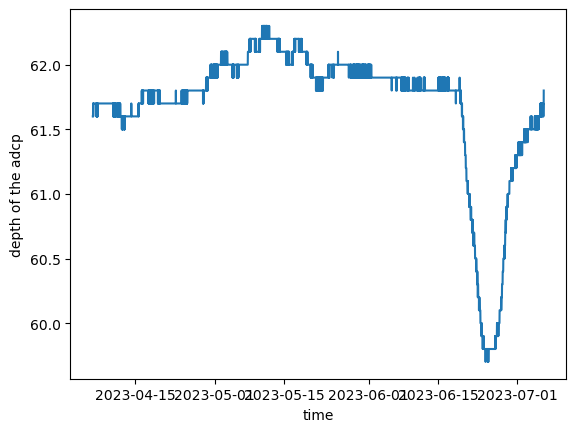

t_in = 2023-04-06T09:50:00.000000000 
 t_out = 2023-07-06T07:40:00.000000000
deep of the adcp = 61.69154357910156 m 


In [11]:
grad=adcp.depth.diff(dim='time')


i,j=np.argmax(grad.values),np.argmin(grad.values)

t_in,t_out=adcp.time.values[i+2],adcp.time.values[j-1]

fig,ax=plt.subplots()
ax.plot(adcp.time.sel(time=slice(t_in,t_out)),adcp.depth.sel(time=slice(t_in,t_out)))
ax.set_ylabel('depth of the adcp')
ax.set_xlabel('time')
plt.show()

print(f't_in = {t_in} \n t_out = {t_out}')
high=adcp.depth.isel(time=slice(i+2,j)).mean().item()
print(f'deep of the adcp = {high} m ')


In [12]:

realdepth=high-adcp.range.values
adcpcorr=adcp.assign_coords(realdepth=('range',realdepth))
adcpcorr=adcpcorr.where((adcpcorr.time >= t_in) & (adcpcorr.time <= t_out) , drop=True)
#adcpcorr=adcpcorr.where(adcpcorr.realdepth >= 0, drop=True)
adcpcorr



<xarray.Dataset> Size: 37MB
Dimensions:              (time: 13092, dir: 4, range: 40, beam: 4, x: 4, x*: 4,
                          earth: 3, inst: 3)
Coordinates:
  * time                 (time) datetime64[ns] 105kB 2023-04-06T09:50:00 ... ...
  * dir                  (dir) <U3 48B 'E' 'N' 'U' 'err'
  * range                (range) float64 320B 3.09 5.09 7.09 ... 79.09 81.09
    realdepth            (range) float64 320B 58.6 56.6 54.6 ... -17.4 -19.4
  * beam                 (beam) int64 32B 1 2 3 4
  * x                    (x) int64 32B 1 2 3 4
  * x*                   (x*) int64 32B 1 2 3 4
  * earth                (earth) <U1 12B 'E' 'N' 'U'
  * inst                 (inst) <U1 12B 'X' 'Y' 'Z'
Data variables: (12/21)
    number               (time) float64 105kB 888.0 889.0 ... 1.398e+04
    builtin_test_fail    (time) float64 105kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    c_sound              (time) float32 52kB 1.436e+03 1.436e+03 ... 1.433e+03
    depth                (time) float32 52kB 61.6 61.6 61.6 ... 61.7 61.7 61.8
    pitch                (time) float32 52kB -1.06 -1.06 -1.06 ... -1.17 -1.14
    roll                 (time) float32 52kB -1.0 -1.0 -0.98 ... -0.77 -0.81
    ...                   ...
    vel                  (dir, range, time) float32 8MB -0.01 -0.018 ... nan nan
    amp                  (beam, range, time) float32 8MB 126.0 116.0 ... 41.0
    corr                 (beam, range, time) float32 8MB 119.0 121.0 ... 9.0
    prcnt_gd             (beam, range, time) float32 8MB 0.0 0.0 0.0 ... 0.0 0.0
    beam2inst_orientmat  (x, x*, time) float64 2MB 1.462 1.462 ... -1.034 -1.034
    orientmat            (earth, inst, time) float64 943kB -0.7157 ... -0.9997
Attributes: (12/39)
    inst_make:                TRDI
    inst_type:                ADCP
    rotate_vars:              vel
    has_imu:                  0
    prog_ver:                 51.42
    inst_model:               Workhorse
    ...                       ...
    transmit_lag_m:           0.24
    bandwidth:                0
    power_level:              255
    serialnum:                24399
    fs:                       0.0016680567139282735
    vel_gps_corrected:        0

In [13]:
adcpcorr.realdepth[0]

<xarray.DataArray 'realdepth' ()> Size: 8B
array(58.60154358)
Coordinates:
    range      float64 8B 3.09
    realdepth  float64 8B 58.6

### Flux

In [14]:
depthbound=[np.max(depthprofil)]
for i in range(len(adcpcorr.realdepth)-1):
    if adcpcorr.realdepth[i]>0:
        depthbound.append((adcpcorr.realdepth[i]+adcpcorr.realdepth[i+1]).item()/2)
depthbound=np.array(depthbound)
depthbound[depthbound<0]=0

In [48]:
depthbound


array([113.6387    ,  57.60154358,  55.60154358,  53.60154358,
        51.60154358,  49.60154358,  47.60154358,  45.60154358,
        43.60154358,  41.60154358,  39.60154358,  37.60154358,
        35.60154358,  33.60154358,  31.60154358,  29.60154358,
        27.60154358,  25.60154358,  23.60154358,  21.60154358,
        19.60154358,  17.60154358,  15.60154358,  13.60154358,
        11.60154358,   9.60154358,   7.60154358,   5.60154358,
         3.60154358,   1.60154358,   0.        ])

In [110]:
newdepthbound=[depthbound[0]]
Bool=True

for i in range (1,len(depthbound)):
    if (newdepthbound[-1]-depthbound[i])>11:
        newdepthbound.append(depthbound[i])
        

newdepthbound.append(depthbound[-1])
newdepthbound      
    
        



[np.float64(113.63869999999997),
 np.float64(57.60154357910156),
 np.float64(45.60154357910156),
 np.float64(33.60154357910156),
 np.float64(21.60154357910156),
 np.float64(9.601543579101559),
 np.float64(0.0)]

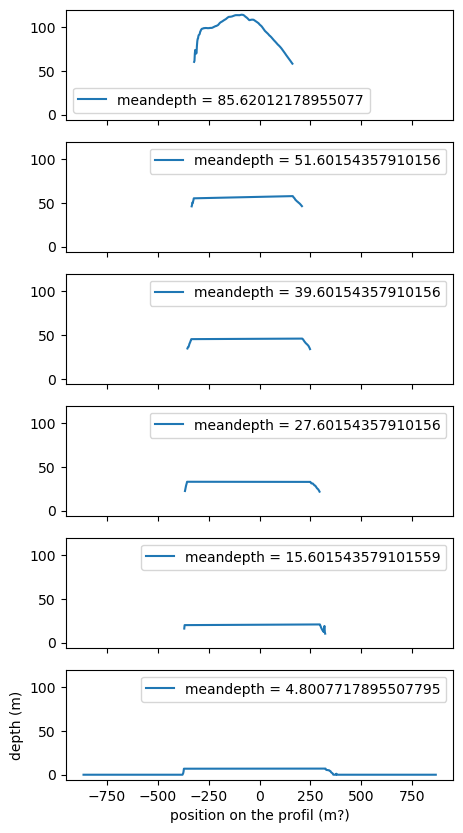

array([ 1742.11553548,   346.16533736,  1777.83185536, ...,
        2404.88113126,   973.11153631, -2189.67081417], shape=(13092,))

In [114]:
Fluxperdepth=[]
fig,ax=plt.subplots(len(newdepthbound)-1,1,sharex=True,sharey=True,figsize=(5, 10))
ax[-1].set_xlabel('position on the profil (m?)')
ax[-1].set_ylabel('depth (m)')

for i in range(len(newdepthbound)-1):
    profilatdepthk=[]
    depthatdepthk=[]
    for j in range (len(coordsprofil)):
        if newdepthbound[i]>=depthprofil[j]>=newdepthbound[i+1]:
            profilatdepthk.append(coordsprofil[j])
            depthatdepthk.append(depthprofil[j])
    #get all the depth that is in in the velocity range (between newdepthbound)
    profilatdepthk,depthatdepthk=np.array(profilatdepthk),np.array(depthatdepthk)
    
    
    ax[i].plot(profilatdepthk,depthatdepthk,label=f'meandepth = {(newdepthbound[i]+newdepthbound[i+1])/2}')
    ax[i].legend()


    surfaceatdepthk=sci.integrate.trapezoid(depthatdepthk-newdepthbound[i+1],profilatdepthk)
    
    u=adcpcorr.vel.sel(dir='N').sel(realdepth=slice(newdepthbound[i],newdepthbound[i+1])).mean(dim='range',skipna=True)
    v=adcpcorr.vel.sel(dir='E').sel(realdepth=slice(newdepthbound[i],newdepthbound[i+1])).mean(dim='range',skipna=True)

    nx=np.sqrt(3)*2
    ny=-np.sqrt(3)*1
    
    fluxatdepthk=surfaceatdepthk*(nx*v+ny*u)
    #integrate at every depth, to deduce the Flux at a given depth
    Fluxperdepth.append(fluxatdepthk.values)
    
Fluxperdepth=np.array(Fluxperdepth)
Flux=np.sum(Fluxperdepth,axis=0)


plt.show()
Flux

In [ ]:

coordsprofilinterp,depthprofilinterp=interpolate(coordsprofil,depthprofil,8)

Fluxperdepth=[]

for i in range(len(depthbound)-1):
    profilatdepthk=[]
    depthatdepthk=[]
    for j in range (len(coordsprofilinterp)):
        if depthbound[i]>=depthprofilinterp[j]>=depthbound[i+1]:
            profilatdepthk.append(coordsprofilinterp[j])
            depthatdepthk.append(depthprofilinterp[j])
    #get all the depth that is in in the velocity range (between depthbound)
    profilatdepthk,depthatdepthk=np.array(profilatdepthk),np.array(depthatdepthk)
    
    surfaceatdepthk=sci.integrate.trapezoid(depthatdepthk-depthbound[i+1],profilatdepthk)
    
    u=adcpcorr.vel.sel(dir='N').isel(range=i)
    v=adcpcorr.vel.sel(dir='E').isel(range=i)
    for itime in range(len(u)):
        if i!= 0 and i!=len(u)-1 and np.isnan(u[itime]) :
            u[itime]=np.nanmean([adcpcorr.vel.sel(dir='N').isel(range=i-1)[itime].item(),adcpcorr.vel.sel(dir='N').isel(range=i+1)[itime].item()])
     
        if i!= 0 and i!=len(u)-1 and np.isnan(v[itime]) :
            v[itime]=np.nanmean([adcpcorr.vel.sel(dir='E').isel(range=i-1)[itime].item(),adcpcorr.vel.sel(dir='E').isel(range=i+1)[itime].item()])


    nx=np.sqrt(3)*2
    ny=-np.sqrt(3)*1
    
    fluxatdepthk=surfaceatdepthk*(nx*v+ny*u)
    #integrate at every depth, to deduce the Flux at a given depth
    
    Fluxperdepth.append(fluxatdepthk.values)
    
Fluxperdepth=np.array(Fluxperdepth)
Flux=np.sum(Fluxperdepth,axis=0)
Flux




array([ 2589.54072664,  1281.70298226,  2896.50026312, ...,
        2338.88982183,   815.33620485, -2435.79123014], shape=(13092,))

Text(0, 0.5, 'Flux (S-E) (m3.s-1)')

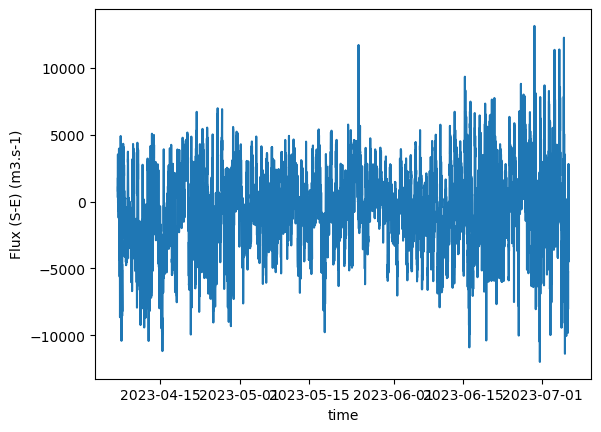

In [93]:
fig,ax=plt.subplots()
ax.plot(adcpcorr.time,Flux)
ax.set_xlabel('time')
ax.set_ylabel('Flux (S-E) (m3.s-1)')

In [125]:
newdepthbound

[np.float64(113.63869999999997),
 np.float64(57.60154357910156),
 np.float64(45.60154357910156),
 np.float64(33.60154357910156),
 np.float64(21.60154357910156),
 np.float64(9.601543579101559),
 np.float64(0.0)]

btwn 9 and 45m, no oscillations (first graph)

But there is above and bellow (2 next graph)

mean of data = -167.88686475190525


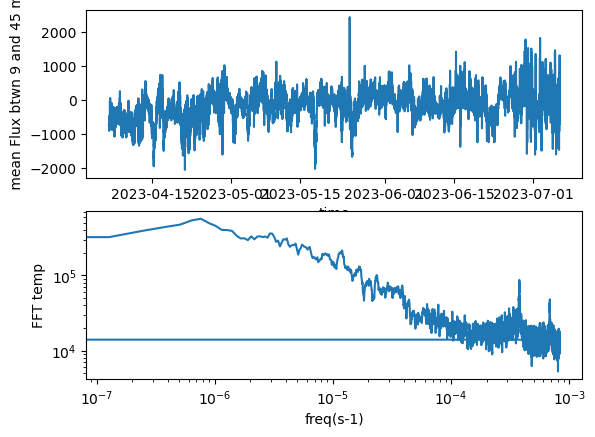

In [130]:

data=np.mean([Fluxperdepth[-3,:],Fluxperdepth[-4,:],Fluxperdepth[-2,:]],axis=0)

TF,freq=plot_and_TF(data,adcpcorr,' mean Flux btwn 9 and 45 m')

mean of data = -59.20162801526329


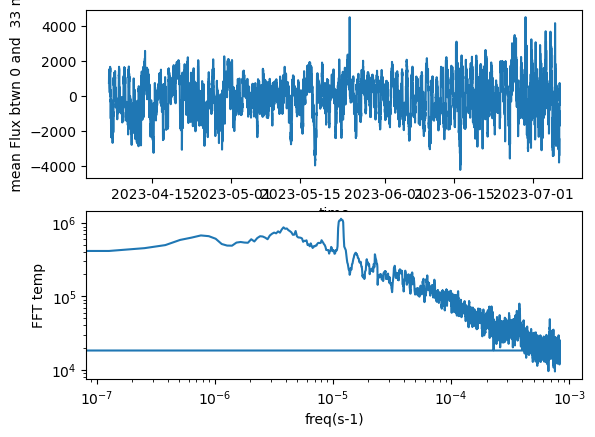

In [140]:
data=np.mean(Fluxperdepth[-3:,:],axis=0)

TFabove,freq=plot_and_TF(data,adcpcorr,' mean Flux btwn 0 and  33 m')

In [149]:
Pabove

array([   92,  2973,  5383,  7710, 10120, 13001])

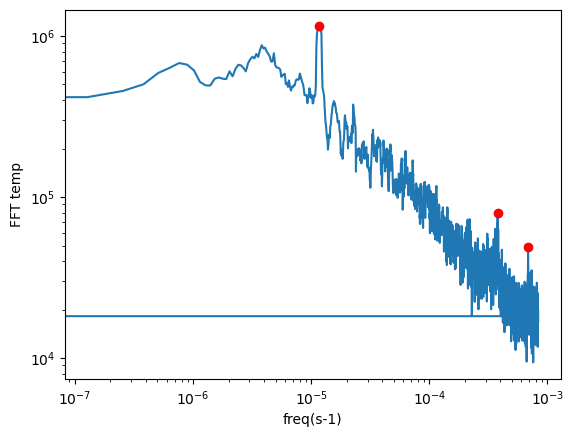

np.float64(23.717391304347828)

In [152]:
g = np.ones(10)/10
FFTsmooth = np.convolve(np.abs(TFabove),g,'same')


Pabove,_=sci.signal.find_peaks(FFTsmooth,height=10000,distance=2000,prominence=1000)



fig,ax=plt.subplots()


ax.loglog(freq,FFTsmooth)
ax.loglog(freq[Pabove],FFTsmooth[Pabove],'o',color='red')
ax.set_ylabel('FFT temp')
ax.set_xlabel('freq(s-1)')
plt.show()
(1/freq[Pabove[0]])/(60*60)


mean of data = -142.1286128236493


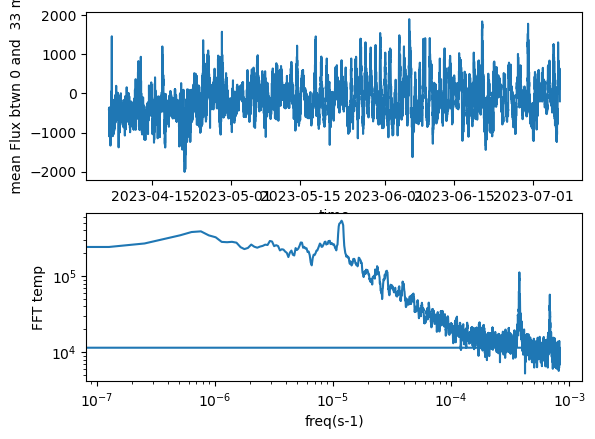

In [153]:
data=np.mean(Fluxperdepth[:-2,:],axis=0)

TFbellow,freq=plot_and_TF(data,adcpcorr,' mean Flux btwn 0 and  33 m')

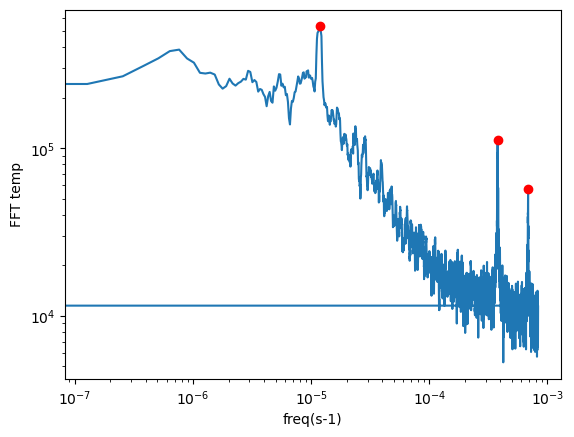

np.float64(1.8274706867671693)

In [186]:
g = np.ones(10)/10
FFTsmooth = np.convolve(np.abs(TFbellow),g,'same')


Pbellow,_=sci.signal.find_peaks(FFTsmooth,height=10000,distance=2000,prominence=1000)



fig,ax=plt.subplots()


ax.loglog(freq,FFTsmooth)
ax.loglog(freq[Pbellow],FFTsmooth[Pbellow],'o',color='red')
ax.set_ylabel('FFT temp')
ax.set_xlabel('freq(s-1)')
plt.show()
(1/freq[P[0]])/(60*60)


In [165]:
np.mean(np.angle(TFabove[Pabove[0]-20:Pabove[0]+20])*360/np.pi)

np.float64(-61.146931763543556)

In [166]:
np.mean(np.angle(TFbellow[Pbellow[0]-20:Pbellow[0]+20])*360/np.pi)

np.float64(41.36397076153679)

In [173]:
TFabove

array([ 5.05679054e-10+8.27640179e-11j, -4.72938731e+05+4.09153803e+05j,
       -3.94044679e+04+7.58514267e+05j, ...,
       -1.00661911e+06-8.00441846e+05j, -3.94044679e+04-7.58514267e+05j,
       -4.72938731e+05-4.09153803e+05j], shape=(13092,))

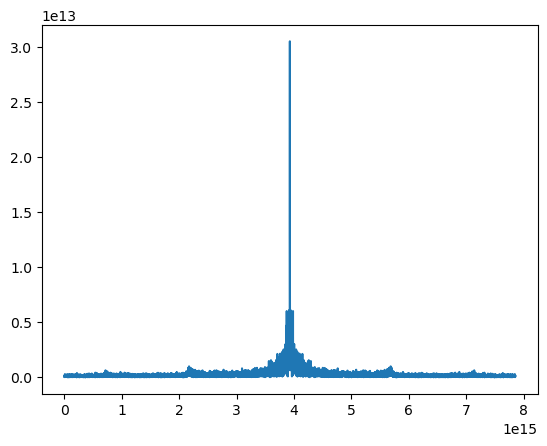

In [192]:
crosscorr=np.abs(sci.signal.correlate(TFabove,TFbellow,mode='same'))
fig,ax=plt.subplots()

ax.plot(adcpcorr.time-adcpcorr.time[0],crosscorr)
plt.show()

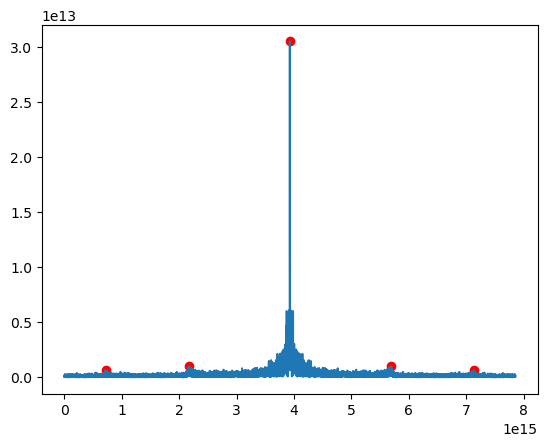

<xarray.DataArray 'time' (time: 5)> Size: 40B
array([ 8.29166667, 25.13194444, 45.45833333, 65.78472222, 82.625     ])
Coordinates:
  * time     (time) datetime64[ns] 40B 2023-04-14T16:50:00 ... 2023-06-28T00:...
Attributes:
    coverage_content_type:  coordinate
    long_name:              Time
    standard_name:          time

In [202]:
P,_=sci.signal.find_peaks(crosscorr,height=10000,distance=2000,prominence=1000)



fig,ax=plt.subplots()

ax.plot(adcpcorr.time[P]-adcpcorr.time[0],crosscorr[P],'o',color='red')
ax.plot(adcpcorr.time-adcpcorr.time[0],crosscorr)
plt.show()

(1/freq[P[0]])/(60*60)
(adcpcorr.time[P]-adcpcorr.time[0])/np.timedelta64(1,'D')

### About velocity

mean of data = 0.0034774240389909344


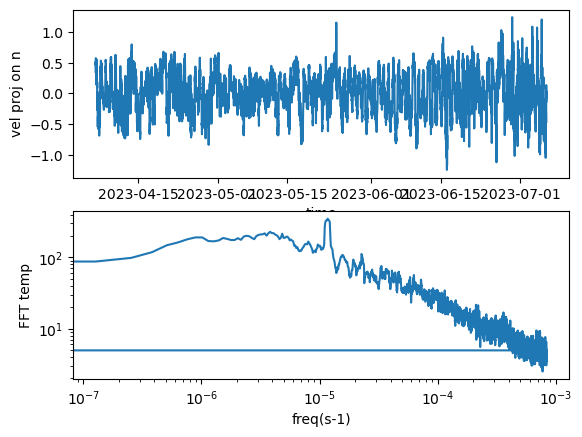

In [ ]:
u=adcpcorr.vel.sel(realdepth=slice(20,0)).sel(dir='N').mean(dim='range')
v=adcpcorr.vel.sel(realdepth=slice(20,0)).sel(dir='E').mean(dim='range')

nx=np.sqrt(3)*2
ny=-np.sqrt(3)*1
    
proj=(nx*v+ny*u)

data=proj

_=plot_and_TF(data,adcpcorr,'vel proj on n btwn 0 and 20m')

mean of data = -0.012651445736594926


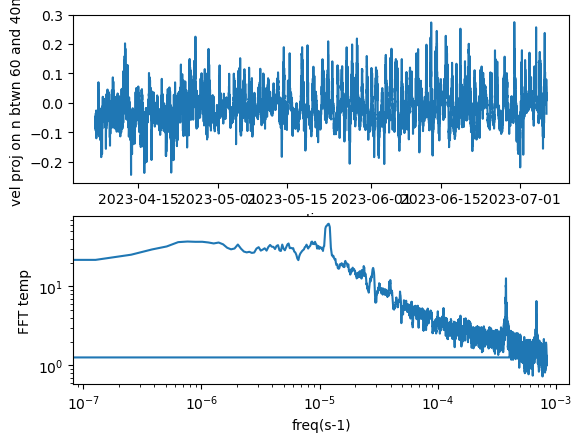

In [216]:
u=adcpcorr.vel.sel(realdepth=slice(60,40)).sel(dir='N').mean(dim='range')
v=adcpcorr.vel.sel(realdepth=slice(60,40)).sel(dir='E').mean(dim='range')

nx=np.sqrt(3)*2
ny=-np.sqrt(3)*1
    
proj=(nx*v+ny*u)

data=proj

_=plot_and_TF(data,adcpcorr,'vel proj on n btwn 60 and 40m')

mean of data = 0.07956736534833908


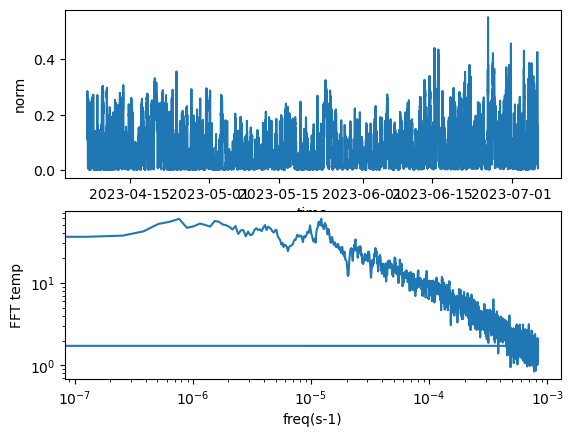

In [213]:
u=adcpcorr.vel.sel(realdepth=slice(10,0),dir='N')
v=adcpcorr.vel.sel(realdepth=slice(10,0),dir='E')
w=adcpcorr.vel.sel(realdepth=slice(10,0),dir='U')

N=(u*u+v*v+w*w).mean(dim='range')

data=N

_=plot_and_TF(data,adcpcorr,'norm')

# Thermister

In [218]:
os.listdir('../data/adcp/')
fp='../data/'
os.listdir(fp)


['adcp', 'bathymetry.nc', 'CTD']

In [ ]:

adcp=xr.open_dataset(fp)
adcp